Saving Screenshot 2026-09-29 140937.png to Screenshot 2026-09-29 140937.png


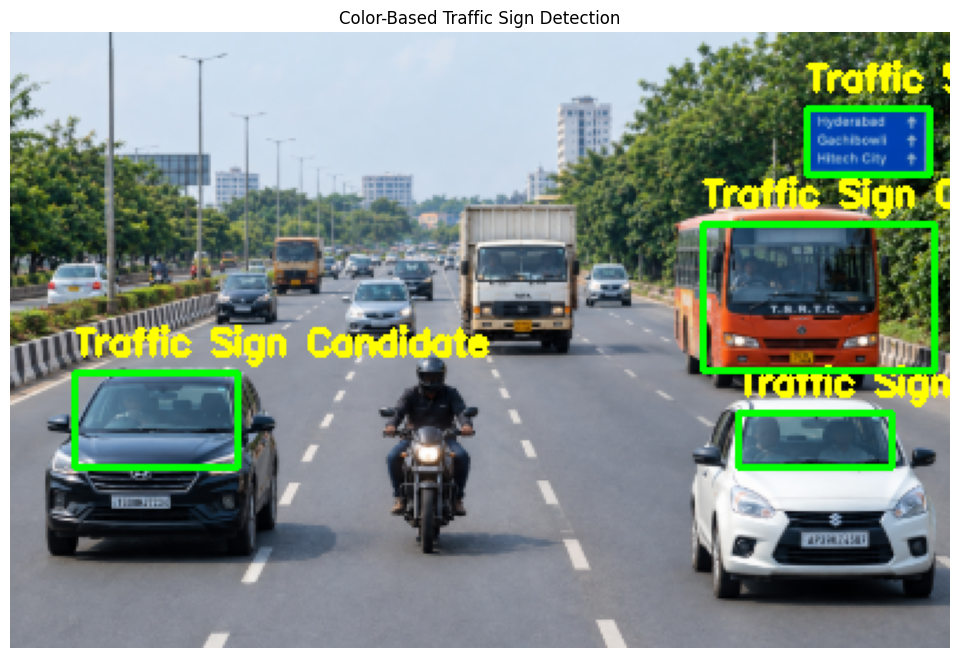

Traffic sign candidates detected: 4


In [1]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
image_path = next(iter(uploaded))

image = cv2.imread(image_path)

if image is None:
    raise ValueError("Unable to read image. Upload a JPG or PNG file.")

output = image.copy()
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

red1 = cv2.inRange(hsv, (0, 80, 80), (10, 255, 255))
red2 = cv2.inRange(hsv, (170, 80, 80), (180, 255, 255))
red = red1 | red2

blue = cv2.inRange(hsv, (90, 70, 50), (135, 255, 255))
yellow = cv2.inRange(hsv, (15, 80, 80), (40, 255, 255))

combined = red | blue | yellow

kernel = np.ones((5, 5), np.uint8)
combined = cv2.morphologyEx(combined, cv2.MORPH_OPEN, kernel)
combined = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, kernel)

contours, _ = cv2.findContours(
    combined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

count = 0

for cnt in contours:
    area = cv2.contourArea(cnt)

    if area < 500:
        continue

    x, y, w, h = cv2.boundingRect(cnt)
    ratio = w / float(h)

    if 0.5 <= ratio <= 3.0 and w >= 20 and h >= 15:
        region = combined[y:y+h, x:x+w]
        color_pixels = cv2.countNonZero(region)

        if color_pixels / float(w * h) < 0.25:
            continue

        cv2.rectangle(output, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(
            output, "Traffic Sign Candidate",
            (x, max(y-8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2
        )
        count += 1

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Color-Based Traffic Sign Detection")
plt.axis("off")
plt.show()

print("Traffic sign candidates detected:", count)